In [1]:
%load_ext autoreload
%autoreload 2

12.0055850055


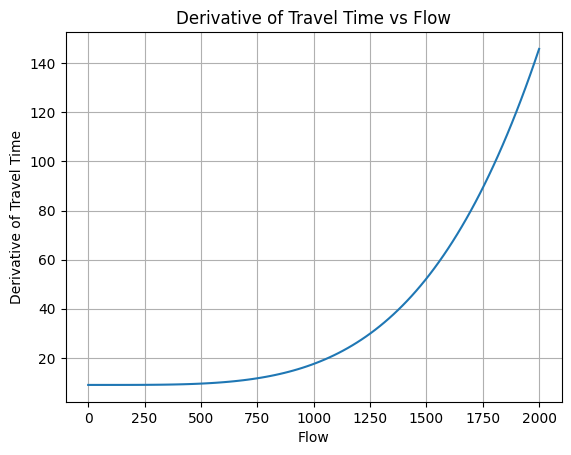

In [19]:
import matplotlib.pyplot as plt
import numpy as np
import hashlib

student_id = "403209743"
seed = int(hashlib.sha256(student_id.encode()).hexdigest(), 16)
seed = seed % (10**8)
B = 0.15 + (int(seed) % 10) / 100
T0 = 5 + (int(seed) % 10)
C = 1000
K = 12
def travel_time(f):
    # f = np.asarray(f)
    y = T0 * (1 + B * (f / C)**4)
    return y * f

def der_ftravel_time(f):
    y = T0 * (1 + 5 * B * (f / C)**4)
    return y

f = np.linspace(0, 2000, 100)
rg = der_ftravel_time(f)
print(der_ftravel_time(770))
plt.plot(f, rg)
plt.xlabel("Flow")
plt.ylabel("Derivative of Travel Time")
plt.title("Derivative of Travel Time vs Flow")
plt.grid()
plt.show()

In [18]:
from modular.optimization_algorithms import BiSection
optim = BiSection(loss_function=travel_time, a=0, b=C, epsilon=1e-5)
x_bi, y_bi = optim.step(epsilon=1e-5, log=True, K=K)
x_bi, y_bi = round(x_bi), round(y_bi)
# p1 = int(hash(tuple([x_bi, y_bi])) % 1e5)
print(x_bi, y_bi)

[Success] Converged at step=25
770 7389


In [62]:
SAFE_EDGES = [
    (3,4), (4,3),
    (4,5), (5,4),
    (5,6), (6,5),
    (6,8), (8,6),
    (7,8), (8,7),
    (9,10), (10,9),
    (10,11), (11,10),
    (11,12), (12,11),
    (12,13), (13,12),
    (14,15), (15,14),
    (15,19), (19,15),
    (16,17), (17,16),
    (16,18), (18,16),
    (20,21), (21,20),
    (21,22), (22,21),
    (22,23), (23,22),
    (23,24), (24,23)]

In [63]:
import numpy as np
from student_info import students
import hashlib

def generate_network(student_id: str):
    seed = int(hashlib.sha256(student_id.encode()).hexdigest(), 16)
    seed = seed % (10**8)

    rng = np.random.default_rng(seed)
    indices = rng.choice(len(SAFE_EDGES), size=5, replace=False)

    C = 1000.0

    # --- Simple generation ---
    network = {}
    for i in indices:
        edge = SAFE_EDGES[i]
        
        x = rng.integers(500, 900)
        
        # randomly increase or decrease (controlled)
        change = rng.uniform(0.3, 0.6) * x
        if rng.random() < 0.5:
            y = x - change
        else:
            y = x + change
        
        network[edge] = {
            "x": float(x),
            "y": float(max(0.0, y)),
            "t0": float(rng.integers(5, 25)),
            "B": float(0.15 + 0.25 * rng.random())
        }

    # --- Loss ---
    def loss_function(lmbd):
        total = 0.0
        for edge in network:
            d = network[edge]
            f = d["x"] + lmbd * (d["y"] - d["x"])
            T = d["t0"] * (1 + d["B"] * (f / C) ** 4)
            total += f * T
        return total

    # --- Derivative ---
    def derivative(lmbd, eps=1e-6):
        return (loss_function(lmbd + eps) - loss_function(lmbd - eps)) / (2 * eps)

    # --- Simple correction loop ---
    for _ in range(5):
        if derivative(0) < 0 and derivative(1) > 0:
            break
        
        for edge in network:
            if derivative(0) > 0:
                network[edge]["y"] *= 0.9   # encourage movement
            if derivative(1) < 0:
                network[edge]["y"] *= 1.1   # penalize full move
                
    for k, v in network.items():
        v["x"] = round(v["x"], 2)
        v["y"] = round(v["y"], 2)
        v["t0"] = round(v["t0"], 2)
        v["B"] = round(v["B"], 2)
    return network

In [66]:
network_data = {}
for student, id in students.items():
    network_data[id] = generate_network(id)
output_file_path = r"/Users/keivanjamali/Projects/Pure-Python/P6/04-Transportations_System/Project/data/network_P3.txt"
with open(output_file_path, "w") as f:
    for student_id, network in network_data.items():
        f.write(f"{student_id}: {str(network)}\n")

In [5]:
x_golde, y_golde

(999.9999999931983, np.float64(-52990.559999639554))

In [21]:
st_number = "403209743"
B = 0.15 + (int(st_number) % 10) / 100
K = 10 + (int(st_number) % 50)
T0 = 5 + (int(st_number) % 10)
c = 1000

def loss_function(x):
    x = np.asarray(x)
    y = T0 * (1 + B * (x / c)**4)
    return y

optim = BiSection(loss_function=loss_function, a=0, b=1000000, epsilon=1e-5)
x_bi, y_bi = optim.step(epsilon=0.001, log=True, K=K)

[Success] Converged at step=35


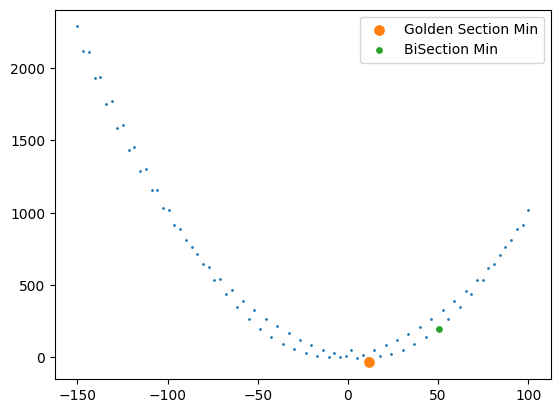

In [46]:
import matplotlib.pyplot as plt
import numpy as np

x = np.linspace(-150, 100, 80)
y = loss_function(x)

plt.scatter(x, y, s=1)
plt.scatter(x_golde, y_golde, label="Golden Section Min", s=45)
plt.scatter(x_bi, y_bi, label="BiSection Min", s=15)
plt.legend()
plt.show()